# Heart Disease Dataset — Preprocessing

**Objective:** Clean and prepare the data for modelling.  

Based on the EDA findings, the following steps are required:

| Step | Reason |
|---|---|
| Drop duplicates | 723 duplicate rows found in EDA |
| Remove thal=0 rows | Only 2 patients; value represents missing data |
| Handle outliers | Extreme values in `chol`, `trestbps`, `thalach`, `oldpeak` |
| Log transform `oldpeak` | Heavy right skew observed in EDA |
| Encode categoricals | SVM and Logistic Regression require numeric input |
| Scale continuous features | Required for SVM and Logistic Regression; not needed for tree-based models but applied for consistency |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import os

os.makedirs('../plots', exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Raw Dataset

In [2]:
# Load the original raw dataset — preprocessing starts from scratch here
df = pd.read_csv('../data/heart.csv')
print(f'Raw dataset shape: {df.shape}')
df.head()

Raw dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Remove Duplicates

In [3]:
# 723 duplicate rows were identified in EDA — remove them
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f'Rows before: {before}')
print(f'Rows after:  {after}')
print(f'Duplicates removed: {before - after}')

Rows before: 1025
Rows after:  302
Duplicates removed: 723


## 4. Remove Invalid thal=0 Rows

In [4]:
# thal=0 represents missing/no data (only 2 patients) — not a valid clinical category
# Keeping them would introduce noise rather than signal
before = df.shape[0]
df = df[df['thal'] != 0].reset_index(drop=True)
after = df.shape[0]

print(f'Rows removed (thal=0): {before - after}')
print(f'Dataset shape after removal: {df.shape}')
print(f'\nthal value counts after removal:')
print(df['thal'].value_counts().sort_index())

Rows removed (thal=0): 2
Dataset shape after removal: (300, 14)

thal value counts after removal:
thal
1     18
2    165
3    117
Name: count, dtype: int64


## 5. Outlier Detection & Treatment

From EDA, outliers were identified in `chol`, `trestbps`, `thalach`, and `oldpeak`.  
We use **IQR capping (Winsorization)** — clipping extreme values to the 1st and 99th percentile rather than dropping them, to preserve as many rows as possible given the small dataset size.

In [5]:
def cap_outliers(df, col, lower_pct=0.01, upper_pct=0.99):
    """
    Cap outliers at the given percentiles (Winsorization).
    Preferred over dropping rows when the dataset is small.
    """
    lower = df[col].quantile(lower_pct)
    upper = df[col].quantile(upper_pct)
    capped = df[col].clip(lower, upper)
    n_affected = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: capped {n_affected} values | bounds [{lower:.2f}, {upper:.2f}]')
    return capped

# Apply capping to features with outliers identified in EDA
outlier_features = ['chol', 'trestbps', 'thalach', 'oldpeak']

print('Outlier capping summary:')
for col in outlier_features:
    df[col] = cap_outliers(df, col)

Outlier capping summary:
chol: capped 6 values | bounds [148.92, 407.02]
trestbps: capped 4 values | bounds [100.00, 180.00]
thalach: capped 6 values | bounds [94.95, 192.02]
oldpeak: capped 3 values | bounds [0.00, 4.20]


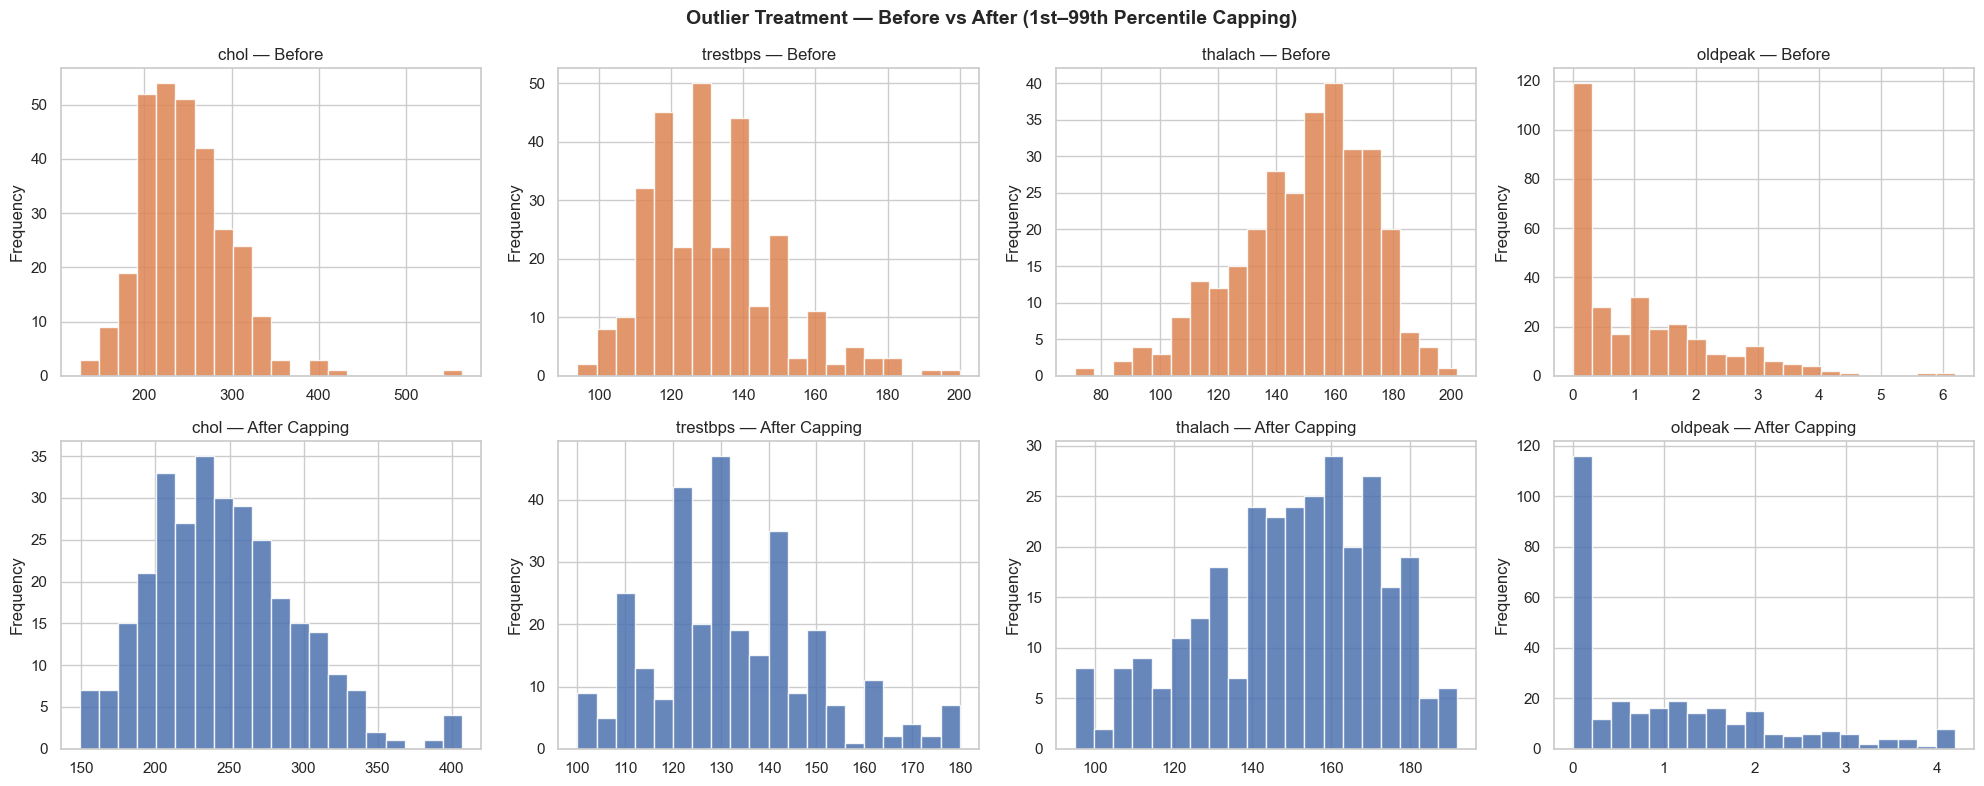

In [7]:
# Visualise distributions before vs after capping to confirm outliers are handled
# (re-load original clean data for comparison)
df_original = pd.read_csv('../data/heart.csv').drop_duplicates().reset_index(drop=True)
df_original = df_original[df_original['thal'] != 0].reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(outlier_features):
    # Before
    axes[0, i].hist(df_original[col], bins=20, color='#DD8452', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Before')
    axes[0, i].set_ylabel('Frequency')

    # After
    axes[1, i].hist(df[col], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col} — After Capping')
    axes[1, i].set_ylabel('Frequency')

plt.suptitle('Outlier Treatment — Before vs After (1st–99th Percentile Capping)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Log Transform `oldpeak`

`oldpeak` was heavily right-skewed in EDA (mean=1.0, many values near 0, tail up to 6.2).  
A log transform compresses the tail and makes the distribution more symmetric,  
which benefits Logistic Regression and SVM.

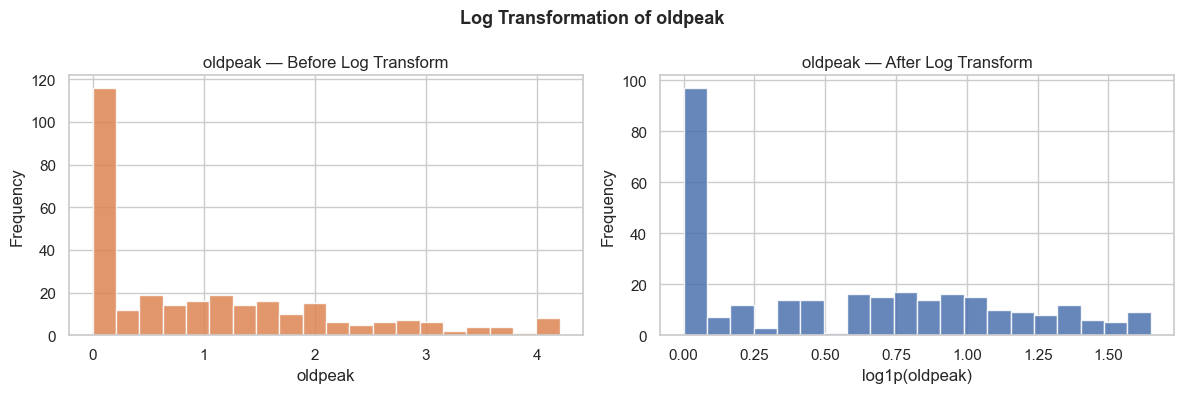

Skewness before: 1.260
Skewness after:  0.347
(Closer to 0 = more symmetric)


In [8]:
# log1p is used instead of log to safely handle zero values (log(0) is undefined)
# log1p(x) = log(x + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# before log transform
axes[0].hist(df['oldpeak'], bins=20, color='#DD8452', edgecolor='white', alpha=0.85)
axes[0].set_title('oldpeak — Before Log Transform')
axes[0].set_xlabel('oldpeak')
axes[0].set_ylabel('Frequency')

# apply log transform
df['oldpeak'] = np.log1p(df['oldpeak'])

# after log transform
axes[1].hist(df['oldpeak'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].set_title('oldpeak — After Log Transform')
axes[1].set_xlabel('log1p(oldpeak)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Log Transformation of oldpeak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/oldpeak_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

# Check skewness improved
print(f'Skewness before: {df_original["oldpeak"].skew():.3f}')
print(f'Skewness after:  {df["oldpeak"].skew():.3f}')
print('(Closer to 0 = more symmetric)')

## 7. Encode Categorical Features

All features are already numeric in this dataset, but some are **ordinal** (ordered categories)  
and some are **nominal** (unordered categories).  

Nominal features with more than 2 categories need **one-hot encoding** to avoid implying  
a false order (e.g. telling the model that `cp=3` is 'greater than' `cp=1`).

In [9]:
# Nominal features — no natural order, must be one-hot encoded
# drop_first=True drops one category per feature to avoid multicollinearity
# (known as the dummy variable trap)
nominal_features = ['cp', 'restecg', 'thal']

df = pd.get_dummies(df, columns=nominal_features, drop_first=True)

print('Columns after one-hot encoding:')
print(df.columns.tolist())
print(f'\nDataset shape: {df.shape}')

Columns after one-hot encoding:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_2', 'thal_3']

Dataset shape: (300, 18)


In [10]:
# Binary and ordinal features — already numeric, no encoding needed
# sex, fbs, exang: already 0/1 binary
# slope, ca: ordinal — numeric order is meaningful (0 < 1 < 2)
print('Binary/ordinal features left as-is:')
print(['sex', 'fbs', 'exang', 'slope', 'ca'])

Binary/ordinal features left as-is:
['sex', 'fbs', 'exang', 'slope', 'ca']


## 8. Split Features and Target

In [11]:
# Separate input features (X) from the target variable (y)
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nFeature columns: {X.columns.tolist()}')
print(f'\nTarget distribution:')
print(y.value_counts())

Features (X): (300, 17)
Target  (y): (300,)

Feature columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_2', 'thal_3']

Target distribution:
target
1    163
0    137
Name: count, dtype: int64


## 9. Train / Test Split

In [12]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
# stratify=y ensures both splits maintain the same class ratio as the full dataset
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape[0]} rows')
print(f'Test set:       {X_test.shape[0]} rows')
print(f'\nTraining target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Training set:   240 rows
Test set:       60 rows

Training target distribution:
target
1    130
0    110
Name: count, dtype: int64

Test target distribution:
target
1    33
0    27
Name: count, dtype: int64


## 10. Feature Scaling

**Why scale?**  
Logistic Regression and SVM are sensitive to feature magnitude — a feature ranging  
0–200 (like `trestbps`) will dominate one ranging 0–1 (like `fbs`) without scaling.  
Random Forest and XGBoost are tree-based and scale-invariant, but we scale anyway  
for consistency across all four models.

**StandardScaler** transforms each feature to mean=0, std=1.

In [13]:
# Fit the scaler on training data only — never fit on test data
# Fitting on test data would cause data leakage (the model indirectly 'sees' test values)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print('Scaling complete.')
print(f'\nSample of scaled training data (mean ≈ 0, std ≈ 1):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Scaling complete.

Sample of scaled training data (mean ≈ 0, std ≈ 1):
        age    sex  trestbps   chol    fbs  thalach  exang  oldpeak  slope  \
mean -0.000  0.000    -0.000 -0.000 -0.000   -0.000 -0.000   -0.000  0.000   
std   1.002  1.002     1.002  1.002  1.002    1.002  1.002    1.002  1.002   

         ca   cp_1   cp_2   cp_3  restecg_1  restecg_2  thal_2  thal_3  
mean  0.000 -0.000  0.000 -0.000      0.000      0.000   0.000  -0.000  
std   1.002  1.002  1.002  1.002      1.002      1.002   1.002   1.002  


## 11. Verify Final Dataset

In [14]:
# Final checks before saving
print('=== Final Dataset Summary ===')
print(f'Total samples:     {len(df)}')
print(f'Features:          {X_train_scaled.shape[1]}')
print(f'Training samples:  {X_train_scaled.shape[0]}')
print(f'Test samples:      {X_test_scaled.shape[0]}')
print(f'\nMissing values in X_train: {X_train_scaled.isnull().sum().sum()}')
print(f'Missing values in X_test:  {X_test_scaled.isnull().sum().sum()}')
print(f'\nTarget distribution (train):')
print(y_train.value_counts(normalize=True).round(3))

=== Final Dataset Summary ===
Total samples:     300
Features:          17
Training samples:  240
Test samples:      60

Missing values in X_train: 0
Missing values in X_test:  0

Target distribution (train):
target
1    0.542
0    0.458
Name: proportion, dtype: float64


## 12. Save Preprocessed Data

In [15]:
import os
os.makedirs('data/processed', exist_ok=True)

# Save all four splits for use in notebook 3
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv',         index=False)
y_test.to_csv('../data/processed/y_test.csv',           index=False)

print('Saved to ../data/processed/:')
print('  X_train.csv')
print('  X_test.csv')
print('  y_train.csv')
print('  y_test.csv')
print('\nReady for modelling in 3_modelling.ipynb')

Saved to ../data/processed/:
  X_train.csv
  X_test.csv
  y_train.csv
  y_test.csv

Ready for modelling in 3_modelling.ipynb


## 13. Preprocessing Summary

| Step | Action | Reason |
|---|---|---|
| Duplicates | Removed 723 rows | Identical rows bias the model |
| thal=0 | Removed 2 rows | Represents missing data, not a valid category |
| Outliers | Winsorized at 1st–99th percentile | Preserves rows in a small dataset |
| oldpeak | log1p transformation | Reduces heavy right skew |
| Nominal features | One-hot encoded (cp, restecg, thal) | Avoids implying false ordinal order |
| Train/test split | 80/20, stratified | Maintains class ratio in both splits |
| Scaling | StandardScaler fit on train only | Required for SVM and Logistic Regression; prevents data leakage |

**Next Step:** Move to `3_modelling.ipynb` to train XGBoost, Random Forest, SVM, and Logistic Regression.